# Detecting Uncertainty in LLM Responses
**CSCI 544 — Group Project | Methods A, B & C**

**Pipeline:**
1. Load datasets (TriviaQA + TruthfulQA)
2. Query Mistral-7B-Instruct, collect answers + logits
3. Label responses (guessing vs. grounded)
4. Method A — Linguistic Feature Classifier (XGBoost)
5. Method B — Consistency-Based Uncertainty (Sentence-BERT + Semantic Entropy)
6. Method C — Combined Signal Model (MLP: linguistic + entropy + log-probs)
7. Evaluation — AUROC, F1, Spearman (per-method + per-dataset breakdown)
8. Error Analysis — complementarity across methods, failure case inspection
9. Visualizations — label distribution, entropy, feature importance, ROC curves, metrics comparison, error complementarity

**Caching:**
- `model_outputs.pkl` — greedy inference outputs (skip re-running ~14 min inference)
- `token_logprobs.pkl` — token-level log-probabilities (required for Method C resume)
- `sampled_answers.json` — K=5 sampled responses per question (skip ~62 min sampling)
- `mlp_best.pt` — best Method C checkpoint by dev AUROC

**Datasets:** TriviaQA (8,000 samples) + TruthfulQA (817 samples) | 80/10/10 split

**Model:** Mistral-7B-Instruct-v0.3 | fp16 | NVIDIA RTX 5090

## 0. Install & Imports

In [1]:
!pip install transformers accelerate datasets sentence-transformers xgboost scikit-learn scipy bitsandbytes -q


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pickle, pandas as pd, torch, numpy as np
from transformers import AutoTokenizer, AutoModelForCausalLM
from sentence_transformers import SentenceTransformer

SEED = 42
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load cached data
with open('model_outputs.pkl', 'rb') as f:
    model_outputs = pickle.load(f)
with open('all_items.pkl', 'rb') as f:
    all_items = pickle.load(f)

print(f'Loaded {len(model_outputs)} outputs')
print(f'Device: {device}')

c:\Users\Harsh\Desktop\NLP Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 8817 outputs
Device: cuda


In [3]:
import os
import re
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
from collections import defaultdict

# HuggingFace
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

# ML
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.cluster import AgglomerativeClustering
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM: 34.2 GB


## 1. Load LLM — Mistral-7B-Instruct

In [4]:
MODEL_ID = 'mistralai/Mistral-7B-Instruct-v0.3'

from huggingface_hub import snapshot_download
print('Checking/downloading model weights...')

print('Loading tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

print('Loading model in fp16...')
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map='auto',        
)
model.eval()

print(f'Model loaded on: {next(model.parameters()).device}')

Checking/downloading model weights...
Loading tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading model in fp16...


Loading weights: 100%|██████████| 291/291 [00:19<00:00, 14.64it/s]


Model loaded on: cuda:0


## 2. Load Datasets

In [ ]:

N_TRIVIAQA   = 8000   # samples from TriviaQA
N_TRUTHFULQA = 817    # TruthfulQA 


print('Loading TriviaQA...')
triviaqa_raw = load_dataset('trivia_qa', 'rc.nocontext', split='train')
triviaqa_raw = triviaqa_raw.shuffle(seed=SEED).select(range(N_TRIVIAQA))

print('Loading TruthfulQA...')
truthfulqa_raw = load_dataset('truthful_qa', 'generation', split='validation')

print(f'TriviaQA:   {len(triviaqa_raw)} samples')
print(f'TruthfulQA: {len(truthfulqa_raw)} samples')

Loading TriviaQA...
Loading TruthfulQA...
TriviaQA:   8000 samples
TruthfulQA: 817 samples


In [6]:
def build_triviaqa_items(dataset):
    items = []
    for row in dataset:
        question = row['question']
        aliases  = row['answer']['aliases']          # list of valid answers
        if not aliases:
            continue
        items.append({
            'question':       question,
            'valid_answers':  [a.lower().strip() for a in aliases],
            'source':         'triviaqa'
        })
    return items

def build_truthfulqa_items(dataset):
    items = []
    for row in dataset:
        question       = row['question']
        correct        = row['correct_answers']      # list
        if not correct:
            continue
        items.append({
            'question':      question,
            'valid_answers': [a.lower().strip() for a in correct],
            'source':        'truthfulqa'
        })
    return items

triviaqa_items   = build_triviaqa_items(triviaqa_raw)
truthfulqa_items = build_truthfulqa_items(truthfulqa_raw)
all_items        = triviaqa_items + truthfulqa_items

print(f'Total items: {len(all_items)}')

Total items: 8817


## 3. Query Mistral — Collect Answers + Logits

In [7]:
def make_prompt(question: str) -> str:
    return (
        f'[INST] Answer the following question concisely and factually. '
        f'Give only the answer, no explanation.\n\nQuestion: {question} [/INST]'
    )

@torch.inference_mode()
def query_model_batch(questions: list[str], max_new_tokens=80, batch_size=8):
    """
    Returns list of dicts: {answer, mean_logprob, min_logprob, token_logprobs}
    Batched for GPU throughput.
    """
    results = []
    prompts = [make_prompt(q) for q in questions]

    for i in tqdm(range(0, len(prompts), batch_size), desc='Querying model'):
        batch_prompts = prompts[i:i+batch_size]
        inputs = tokenizer(
            batch_prompts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=512
        ).to(device)

        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,           # greedy — deterministic for logit baseline
            return_dict_in_generate=True,
            output_scores=True,
            pad_token_id=tokenizer.eos_token_id,
        )

        # Decode generated tokens only (strip prompt)
        input_len = inputs['input_ids'].shape[1]
        gen_ids   = outputs.sequences[:, input_len:]

        # Collect per-token log-probs
        # outputs.scores: tuple of (batch, vocab) tensors, one per generated token
        scores_stack = torch.stack(outputs.scores, dim=1)  # (batch, gen_len, vocab)
        log_probs    = torch.log_softmax(scores_stack, dim=-1)

        for b in range(len(batch_prompts)):
            tokens      = gen_ids[b]
            answer_text = tokenizer.decode(tokens, skip_special_tokens=True).strip()

            # Gather log-prob of each chosen token
            token_lps = []
            for t_idx, tok_id in enumerate(tokens):
                if tok_id == tokenizer.eos_token_id:
                    break
                if t_idx < log_probs.shape[1]:
                    token_lps.append(log_probs[b, t_idx, tok_id].item())

            mean_lp = float(np.mean(token_lps)) if token_lps else -10.0
            min_lp  = float(np.min(token_lps))  if token_lps else -10.0

            results.append({
                'answer':         answer_text,
                'mean_logprob':   mean_lp,
                'min_logprob':    min_lp,
                'token_logprobs': token_lps
            })

    return results

In [8]:
questions = [item['question'] for item in all_items]
print(f'Querying model on {len(questions)} questions...')

model_outputs = query_model_batch(questions, max_new_tokens=80, batch_size=16)
print('Done.')

Querying model on 8817 questions...


Querying model: 100%|██████████| 552/552 [13:24<00:00,  1.46s/it]

Done.


In [9]:
import pickle
with open('model_outputs.pkl', 'wb') as f:
    pickle.dump(model_outputs, f)
with open('all_items.pkl', 'wb') as f:
    pickle.dump(all_items, f)
print('Saved!')

Saved!


## 4. Label Responses (Guessing vs. Grounded)

In [10]:
import re
def normalize(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)  # strip punctuation
    text = re.sub(r'\s+', ' ', text)
    return text

def is_correct(predicted: str, valid_answers: list[str]) -> bool:
    pred = normalize(predicted)
    for ans in valid_answers:
        ans_norm = normalize(ans)
        # Exact match or answer is a substring of prediction
        if ans_norm == pred or ans_norm in pred:
            return True
    return False

records = []
for item, output in zip(all_items, model_outputs):
    correct = is_correct(output['answer'], item['valid_answers'])
    records.append({
        'question':       item['question'],
        'valid_answers':  item['valid_answers'],
        'predicted':      output['answer'],
        'label':          0 if correct else 1,   # 1 = guessing
        'mean_logprob':   output['mean_logprob'],
        'min_logprob':    output['min_logprob'],
        'token_logprobs': output['token_logprobs'],
        'source':         item['source']
    })

df = pd.DataFrame(records)
print(df['label'].value_counts())
print(f"Guessing rate: {df['label'].mean():.2%}")
print(df.groupby('source')['label'].mean().rename('guessing_rate'))

label
0    6049
1    2768
Name: count, dtype: int64
Guessing rate: 31.39%
source
triviaqa      0.257000
truthfulqa    0.871481
Name: guessing_rate, dtype: float64


In [11]:
import pickle

df_save = df.drop(columns=['token_logprobs', 'valid_answers'])
df_save.to_csv('labeled_data.csv', index=False)
print('Saved labeled_data.csv')

# Save token_logprobs separately so Method C can resume without re-running inference
token_logprobs_cache = df['token_logprobs'].tolist()
with open('token_logprobs.pkl', 'wb') as f:
    pickle.dump(token_logprobs_cache, f)
print('Saved token_logprobs.pkl')

Saved labeled_data.csv
Saved token_logprobs.pkl


## 5. Train / Dev / Test Split

In [12]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(df))
labels = df['label'].values

idx_train, idx_temp, y_train_, y_temp_ = train_test_split(
    idx, labels, test_size=0.2, stratify=labels, random_state=SEED)
idx_dev, idx_test, y_dev_, y_test_ = train_test_split(
    idx_temp, y_temp_, test_size=0.5, stratify=y_temp_, random_state=SEED)

df_train = df.iloc[idx_train].reset_index(drop=True)
df_dev   = df.iloc[idx_dev].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

print(f'Train: {len(df_train)} | Dev: {len(df_dev)} | Test: {len(df_test)}')
print(f'Train guessing rate: {df_train["label"].mean():.2%}')
print(f'Dev   guessing rate: {df_dev["label"].mean():.2%}')
print(f'Test  guessing rate: {df_test["label"].mean():.2%}')

Train: 7053 | Dev: 882 | Test: 882
Train guessing rate: 31.39%
Dev   guessing rate: 31.41%
Test  guessing rate: 31.41%


## 6. Method A — Linguistic Feature Classifier (XGBoost)

In [13]:

HEDGE_WORDS = [
    'possibly', 'perhaps', 'maybe', 'likely', 'unlikely', 'probably',
    'i think', 'i believe', 'i am not sure', 'i am not certain',
    'i\'m not sure', 'i\'m not certain', 'it seems', 'it appears',
    'it is possible', 'it may', 'it might', 'it could', 'not sure',
    'unclear', 'uncertain', 'approximately', 'roughly', 'around',
    'might', 'may', 'could', 'should', 'would', 'seems'
]

MODAL_VERBS = ['might', 'may', 'could', 'would', 'should', 'can', 'shall']

def extract_linguistic_features(text: str) -> dict:
    text_lower = text.lower()
    words      = text_lower.split()
    n_words    = max(len(words), 1)

    hedge_count = sum(1 for hw in HEDGE_WORDS if hw in text_lower)
    modal_count = sum(1 for w in words if w in MODAL_VERBS)
    hedge_freq  = hedge_count / n_words
    modal_freq  = modal_count / n_words

    has_question_mark = int('?' in text)
    has_ellipsis      = int('...' in text)

    fp_uncertainty = int(any(p in text_lower for p in ['i think', 'i believe', 'i\'m not', 'i am not']))

    return {
        'answer_length':      n_words,
        'hedge_count':        hedge_count,
        'hedge_freq':         hedge_freq,
        'modal_count':        modal_count,
        'modal_freq':         modal_freq,
        'has_question_mark':  has_question_mark,
        'has_ellipsis':       has_ellipsis,
        'fp_uncertainty':     fp_uncertainty,
        'char_length':        len(text),
    }

def build_feature_matrix(df_split: pd.DataFrame) -> np.ndarray:
    feats = [extract_linguistic_features(row['predicted']) for _, row in df_split.iterrows()]
    return pd.DataFrame(feats).values

print('Extracting linguistic features...')
X_train_A = build_feature_matrix(df_train)
X_dev_A   = build_feature_matrix(df_dev)
X_test_A  = build_feature_matrix(df_test)

y_train = df_train['label'].values
y_dev   = df_dev['label'].values
y_test  = df_test['label'].values

print(f'Feature matrix shape: {X_train_A.shape}')

Extracting linguistic features...
Feature matrix shape: (7053, 9)


In [14]:
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

scaler_A = StandardScaler()
X_train_A_sc = scaler_A.fit_transform(X_train_A)
X_dev_A_sc   = scaler_A.transform(X_dev_A)
X_test_A_sc  = scaler_A.transform(X_test_A)

clf_A = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=SEED,
    tree_method='hist',   
    device='cuda'
)
clf_A.fit(
    X_train_A_sc, y_train,
    eval_set=[(X_dev_A_sc, y_dev)],
    verbose=50
)
print('Method A training complete.')

[0]	validation_0-logloss:0.61531
[50]	validation_0-logloss:0.54949


c:\Users\Harsh\Desktop\NLP Project\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:53:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.55083
[150]	validation_0-logloss:0.55396
[200]	validation_0-logloss:0.55665
[250]	validation_0-logloss:0.55807
[299]	validation_0-logloss:0.56029
Method A training complete.


In [15]:
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from scipy.stats import spearmanr

def evaluate(name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    auroc  = roc_auc_score(y_true, y_prob)
    f1     = f1_score(y_true, y_pred)
    spear  = spearmanr(y_prob, y_true).statistic
    print(f'\n── {name} ──')
    print(f'  AUROC:              {auroc:.4f}')
    print(f'  F1:                 {f1:.4f}')
    print(f'  Spearman:           {spear:.4f}')
    print(classification_report(y_true, y_pred, target_names=['Grounded', 'Guessing']))
    return {'name': name, 'auroc': auroc, 'f1': f1, 'spearman': spear}

prob_A_dev  = clf_A.predict_proba(X_dev_A_sc)[:, 1]
prob_A_test = clf_A.predict_proba(X_test_A_sc)[:, 1]

res_A_dev  = evaluate('Method A — Dev',  y_dev,  prob_A_dev)
res_A_test = evaluate('Method A — Test', y_test, prob_A_test)


── Method A — Dev ──
  AUROC:              0.7197
  F1:                 0.3910
  Spearman:           0.3532
              precision    recall  f1-score   support

    Grounded       0.74      0.93      0.82       605
    Guessing       0.64      0.28      0.39       277

    accuracy                           0.72       882
   macro avg       0.69      0.60      0.61       882
weighted avg       0.71      0.72      0.69       882


── Method A — Test ──
  AUROC:              0.6632
  F1:                 0.3333
  Spearman:           0.2625
              precision    recall  f1-score   support

    Grounded       0.72      0.90      0.80       605
    Guessing       0.54      0.24      0.33       277

    accuracy                           0.70       882
   macro avg       0.63      0.57      0.57       882
weighted avg       0.66      0.70      0.66       882



c:\Users\Harsh\Desktop\NLP Project\venv\Lib\site-packages\xgboost\core.py:751: UserWarning: [17:53:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [16]:
feat_names = [
    'answer_length', 'hedge_count', 'hedge_freq', 'modal_count',
    'modal_freq', 'has_question_mark', 'has_ellipsis', 'fp_uncertainty', 'char_length'
]
importances = clf_A.feature_importances_
for name, imp in sorted(zip(feat_names, importances), key=lambda x: -x[1]):
    print(f'  {name:<25} {imp:.4f}')

  answer_length             0.2374
  char_length               0.2148
  modal_count               0.1304
  has_ellipsis              0.0842
  modal_freq                0.0842
  hedge_freq                0.0714
  has_question_mark         0.0680
  fp_uncertainty            0.0566
  hedge_count               0.0530


## 7. Method B — Consistency-Based Uncertainty (Semantic Entropy)

In [17]:
import json
import os

CACHE_PATH = "sampled_answers.json"

def save_sampled_answers(sampled_answers, questions, path=CACHE_PATH):
    """Save sampled answers with their questions for verification."""
    data = {
        "questions": questions,
        "sampled_answers": sampled_answers,
        "k": K,
    }
    with open(path, "w") as f:
        json.dump(data, f, indent=2)
    print(f"Saved {len(sampled_answers)} entries to {path}")

def load_sampled_answers(path=CACHE_PATH):
    """Load cached sampled answers."""
    with open(path, "r") as f:
        data = json.load(f)
    print(f"Loaded {len(data['sampled_answers'])} entries from {path} (K={data['k']})")
    return data["sampled_answers"], data["questions"]

# --- Run inference only if cache doesn't exist ---
if os.path.exists(CACHE_PATH):
    print(f"Cache found at '{CACHE_PATH}', skipping inference...")
    sampled_answers, cached_questions = load_sampled_answers()

    # Sanity check: make sure questions match
    all_questions = [row['question'] for _, row in df.iterrows()]
    assert cached_questions == all_questions, \
        "Cached questions don't match current df! Delete the cache and re-run."
else:
    print("No cache found. Collecting sampled responses for Method B...")
    print("(This will take a while — K=5 inference passes)")
    all_questions   = [row['question'] for _, row in df.iterrows()]
    sampled_answers = query_model_sampled(all_questions, k=K, batch_size=16)
    save_sampled_answers(sampled_answers, all_questions)

Cache found at 'sampled_answers.json', skipping inference...
Loaded 8817 entries from sampled_answers.json (K=5)


In [18]:
print('Loading Sentence-BERT...')
sbert = SentenceTransformer('all-MiniLM-L6-v2', device=str(device))
print('Sentence-BERT loaded.')

Loading Sentence-BERT...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5116.10it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Sentence-BERT loaded.


In [19]:
def compute_semantic_entropy(answers: list[str], sbert_model, n_clusters_max: int = 5) -> float:
    if len(answers) <= 1:
        return 0.0

    embeddings = sbert_model.encode(answers, normalize_embeddings=True, show_progress_bar=False)

    n_clust = min(n_clusters_max, len(answers))

    clustering = AgglomerativeClustering(
        n_clusters=None,
        distance_threshold=0.3,   
        metric='cosine',
        linkage='average'
    )
    labels = clustering.fit_predict(embeddings)

    unique, counts = np.unique(labels, return_counts=True)
    probs = counts / counts.sum()

    entropy = -np.sum(probs * np.log(probs + 1e-10))
    return float(entropy)

print('Computing semantic entropy for all samples...')
entropy_scores = []
for answers in tqdm(sampled_answers):
    entropy_scores.append(compute_semantic_entropy(answers, sbert))

df['entropy_score'] = entropy_scores
print(f'Mean entropy (guessing=1): ')
print(df.groupby('label')['entropy_score'].mean())

df['entropy_score'] = df['entropy_score'].clip(lower=0)
print('Entropy clipped. Min value:', df['entropy_score'].min())


Computing semantic entropy for all samples...


100%|██████████| 8817/8817 [00:46<00:00, 188.62it/s]

Mean entropy (guessing=1): 
label
0    0.140775
1    0.321085
Name: entropy_score, dtype: float64
Entropy clipped. Min value: 0.0


In [20]:
from sklearn.preprocessing import MinMaxScaler

all_entropy = df['entropy_score'].values.reshape(-1, 1)
norm_scaler = MinMaxScaler()
norm_scaler.fit(all_entropy[idx_train])

prob_B_all  = norm_scaler.transform(all_entropy).flatten()
prob_B_dev  = prob_B_all[idx_dev]
prob_B_test = prob_B_all[idx_test]

res_B_dev  = evaluate('Method B — Dev',  y_dev,  prob_B_dev)
res_B_test = evaluate('Method B — Test', y_test, prob_B_test)


── Method B — Dev ──
  AUROC:              0.6010
  F1:                 0.2242
  Spearman:           0.2051
              precision    recall  f1-score   support

    Grounded       0.71      0.97      0.82       605
    Guessing       0.70      0.13      0.22       277

    accuracy                           0.71       882
   macro avg       0.70      0.55      0.52       882
weighted avg       0.71      0.71      0.63       882


── Method B — Test ──
  AUROC:              0.6041
  F1:                 0.2310
  Spearman:           0.2121
              precision    recall  f1-score   support

    Grounded       0.71      0.98      0.82       605
    Guessing       0.73      0.14      0.23       277

    accuracy                           0.71       882
   macro avg       0.72      0.56      0.53       882
weighted avg       0.72      0.71      0.64       882



## 8. Method C — Combined Signal Model (MLP)

In [21]:
df_train = df.iloc[idx_train].reset_index(drop=True)
df_dev   = df.iloc[idx_dev].reset_index(drop=True)
df_test  = df.iloc[idx_test].reset_index(drop=True)

# Sanity check
assert 'entropy_score' in df_train.columns, 'entropy_score missing — run Method B first'
assert 'mean_logprob'  in df_train.columns, 'mean_logprob missing — run labeling cell first'
print('Columns synced. Preview:')
print(df_train[['entropy_score', 'mean_logprob', 'min_logprob']].head(3))
print(f'Train: {len(df_train)} | Dev: {len(df_dev)} | Test: {len(df_test)}')


Columns synced. Preview:
   entropy_score  mean_logprob  min_logprob
0       0.000000     -0.193312    -1.142045
1       0.500402     -0.066094    -0.258603
2       0.000000     -0.001456    -0.002340
Train: 7053 | Dev: 882 | Test: 882


In [22]:
def build_combined_features(df_split, idx_split=None):
    ling = build_feature_matrix(df_split)

    entropy = df_split['entropy_score'].values.reshape(-1, 1)

    mean_lp = df_split['mean_logprob'].values.reshape(-1, 1)
    min_lp  = df_split['min_logprob'].values.reshape(-1, 1)

    var_lp = np.array([
        np.var(lps) if isinstance(lps, list) and len(lps) > 1 else 0.0
        for lps in df_split['token_logprobs']
    ]).reshape(-1, 1)

    range_lp = (df_split['mean_logprob'] - df_split['min_logprob']).values.reshape(-1, 1)

    interaction = (entropy * np.abs(mean_lp))

    return np.hstack([ling, entropy, mean_lp, min_lp, var_lp, range_lp, interaction])

print('Building combined feature matrices...')
X_train_C = build_combined_features(df_train, idx_train)
X_dev_C   = build_combined_features(df_dev,   idx_dev)
X_test_C  = build_combined_features(df_test,  idx_test)

print(f'Combined feature matrix shape: {X_train_C.shape}')

scaler_C = StandardScaler()
X_train_C_sc = scaler_C.fit_transform(X_train_C)
X_dev_C_sc   = scaler_C.transform(X_dev_C)
X_test_C_sc  = scaler_C.transform(X_test_C)

Building combined feature matrices...
Combined feature matrix shape: (7053, 15)


In [23]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

class GuessingMLPLogits(nn.Module):
    def __init__(self, input_dim):          # ← removed default of 15
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()],
                           dtype=torch.float32).to(device)
print(f'Positive class weight: {pos_weight.item():.3f}')

def to_tensor(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )

train_ds = to_tensor(X_train_C_sc, y_train)
dev_ds   = to_tensor(X_dev_C_sc,   y_dev)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
dev_loader   = DataLoader(dev_ds,   batch_size=256, shuffle=False)

mlp       = GuessingMLPLogits(input_dim=X_train_C_sc.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 120
best_dev_auroc = 0.0
best_state     = None

print(f'Training MLP for {EPOCHS} epochs...')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Dev Loss":>8} | {"Dev AUROC":>9} | {"Dev F1":>6}')
print('-' * 55)

for epoch in range(1, EPOCHS + 1):
    mlp.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = mlp(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(y_batch)
    train_loss /= len(train_ds)

    mlp.eval()
    dev_loss  = 0.0
    dev_probs = []
    with torch.no_grad():
        for X_batch, y_batch in dev_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = mlp(X_batch)
            loss   = criterion(logits, y_batch)
            dev_loss += loss.item() * len(y_batch)
            dev_probs.extend(torch.sigmoid(logits).cpu().numpy())
    dev_loss  /= len(dev_ds)
    dev_probs  = np.array(dev_probs)

    dev_auroc = roc_auc_score(y_dev, dev_probs)
    dev_f1    = f1_score(y_dev, (dev_probs >= 0.5).astype(int))
    scheduler.step(dev_loss)

    if dev_auroc > best_dev_auroc:
        best_dev_auroc = dev_auroc
        best_state     = {k: v.clone() for k, v in mlp.state_dict().items()}

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {dev_loss:>8.4f} | {dev_auroc:>9.4f} | {dev_f1:>6.4f}')

print(f'\nBest dev AUROC: {best_dev_auroc:.4f}')
mlp.load_state_dict(best_state)
print('Best model restored.')

torch.save(best_state, 'mlp_best.pt')
print('Checkpoint saved to mlp_best.pt')

Positive class weight: 2.186
Training MLP for 120 epochs...
 Epoch | Train Loss | Dev Loss | Dev AUROC | Dev F1
-------------------------------------------------------
     1 |     0.8902 |   0.8025 |    0.7802 | 0.6028
    10 |     0.7819 |   0.7844 |    0.7814 | 0.6052
    20 |     0.7715 |   0.7751 |    0.7839 | 0.6071
    30 |     0.7721 |   0.7725 |    0.7840 | 0.6067
    40 |     0.7697 |   0.7707 |    0.7849 | 0.6083
    50 |     0.7659 |   0.7702 |    0.7866 | 0.6029
    60 |     0.7610 |   0.7636 |    0.7871 | 0.6065
    70 |     0.7615 |   0.7633 |    0.7876 | 0.6098
    80 |     0.7616 |   0.7619 |    0.7877 | 0.6067
    90 |     0.7598 |   0.7605 |    0.7885 | 0.6146
   100 |     0.7624 |   0.7604 |    0.7883 | 0.6077
   110 |     0.7575 |   0.7603 |    0.7885 | 0.6097
   120 |     0.7604 |   0.7604 |    0.7884 | 0.6107

Best dev AUROC: 0.7885
Best model restored.
Checkpoint saved to mlp_best.pt


In [24]:
mlp.eval()

def predict_mlp(X_sc):
    X_t = torch.tensor(X_sc, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = mlp(X_t)
        probs  = torch.sigmoid(logits).cpu().numpy()
    return probs

prob_C_dev  = predict_mlp(X_dev_C_sc)
prob_C_test = predict_mlp(X_test_C_sc)

print('Threshold tuning on dev set:')
print(f'  {"Threshold":>9} | {"F1":>6} | {"Recall(guess)":>13} | {"Precision(guess)":>16} | {"AUROC":>6}')
print('  ' + '-' * 60)

from sklearn.metrics import precision_score, recall_score

best_t, best_f1 = 0.5, 0.0
thresholds = [round(t, 2) for t in np.arange(0.15, 0.55, 0.05)]  # wider range
for t in thresholds:
    preds   = (prob_C_dev >= t).astype(int)
    f1_t    = f1_score(y_dev, preds, zero_division=0)
    auroc_t = roc_auc_score(y_dev, prob_C_dev)
    rec_t   = recall_score(y_dev, preds, zero_division=0)
    prec_t  = precision_score(y_dev, preds, zero_division=0)
    print(f'  t={t:.2f}     | {f1_t:.4f} | {rec_t:>13.4f} | {prec_t:>16.4f} | {auroc_t:.4f}')
    if f1_t > best_f1:
        best_f1, best_t = f1_t, t

print(f'\nBest threshold: {best_t} (F1={best_f1:.4f})')

res_C_dev  = evaluate('Method C — Dev',  y_dev,  prob_C_dev,  threshold=best_t)
res_C_test = evaluate('Method C — Test', y_test, prob_C_test, threshold=best_t)

if 'df_test_full' not in dir():
    df_test_full = df.iloc[idx_test].copy()
    df_test_full['prob_A'] = prob_A_test
    df_test_full['prob_B'] = prob_B_test

print('\nPer-dataset breakdown — Method C (Test set):')
df_test_full['prob_C'] = prob_C_test
for source in ['triviaqa', 'truthfulqa']:
    mask = df_test_full['source'] == source
    if mask.sum() < 10:
        continue
    y_s      = df_test_full.loc[mask, 'label'].values
    prob_C_s = df_test_full.loc[mask, 'prob_C'].values
    print(f'  [{source}] n={mask.sum()}')
    print(f'    Method C AUROC: {roc_auc_score(y_s, prob_C_s):.4f}')

import pickle
with open('method_c_probs.pkl', 'wb') as f:
    pickle.dump({'dev': prob_C_dev, 'test': prob_C_test, 'best_threshold': best_t}, f)
print('\nSaved method_c_probs.pkl')

Threshold tuning on dev set:
  Threshold |     F1 | Recall(guess) | Precision(guess) |  AUROC
  ------------------------------------------------------------
  t=0.15     | 0.5222 |        0.9783 |           0.3561 | 0.7885
  t=0.20     | 0.5578 |        0.9675 |           0.3918 | 0.7885
  t=0.25     | 0.5805 |        0.9567 |           0.4167 | 0.7885
  t=0.30     | 0.5845 |        0.9242 |           0.4274 | 0.7885
  t=0.35     | 0.5812 |        0.8592 |           0.4391 | 0.7885
  t=0.40     | 0.5905 |        0.7653 |           0.4807 | 0.7885
  t=0.45     | 0.6006 |        0.7329 |           0.5088 | 0.7885
  t=0.50     | 0.6136 |        0.6823 |           0.5575 | 0.7885

Best threshold: 0.5 (F1=0.6136)

── Method C — Dev ──
  AUROC:              0.7885
  F1:                 0.6136
  Spearman:           0.4639
              precision    recall  f1-score   support

    Grounded       0.84      0.75      0.79       605
    Guessing       0.56      0.68      0.61       277

    accur

## 9. Comparison & Results Summary

In [25]:
majority_prob = np.zeros_like(y_test, dtype=float)   # always predicts grounded
res_baseline  = evaluate('Majority Baseline — Test', y_test, majority_prob)


results = [res_baseline, res_A_test, res_B_test, res_C_test]
summary = pd.DataFrame(results)[['name', 'auroc', 'f1', 'spearman']]
summary.columns = ['Method', 'AUROC', 'F1', 'Spearman']
print('\n' + '='*60)
print('RESULTS SUMMARY (Test Set)')
print('='*60)
print(summary.to_string(index=False))


── Majority Baseline — Test ──
  AUROC:              0.5000
  F1:                 0.0000
  Spearman:           nan
              precision    recall  f1-score   support

    Grounded       0.69      1.00      0.81       605
    Guessing       0.00      0.00      0.00       277

    accuracy                           0.69       882
   macro avg       0.34      0.50      0.41       882
weighted avg       0.47      0.69      0.56       882


RESULTS SUMMARY (Test Set)
                  Method    AUROC       F1  Spearman
Majority Baseline — Test 0.500000 0.000000       NaN
         Method A — Test 0.663243 0.333333  0.262521
         Method B — Test 0.604058 0.231003  0.212121
         Method C — Test 0.765880 0.564935  0.427490


C:\Users\Harsh\AppData\Local\Temp\ipykernel_19372\2775117026.py:8: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  spear  = spearmanr(y_prob, y_true).statistic
c:\Users\Harsh\Desktop\NLP Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harsh\Desktop\NLP Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Harsh\Desktop\NLP Project\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetric

In [26]:
print('\nPer-dataset breakdown (Test set):')
df_test_full = df.iloc[idx_test].copy()
df_test_full['prob_A'] = prob_A_test
df_test_full['prob_B'] = prob_B_test

for source in ['triviaqa', 'truthfulqa']:
    mask = df_test_full['source'] == source
    if mask.sum() < 10:
        continue
    y_s      = df_test_full.loc[mask, 'label'].values
    prob_A_s = df_test_full.loc[mask, 'prob_A'].values
    prob_B_s = df_test_full.loc[mask, 'prob_B'].values
    print(f'\n  [{source}] n={mask.sum()}')
    print(f'    Method A AUROC: {roc_auc_score(y_s, prob_A_s):.4f}')
    print(f'    Method B AUROC: {roc_auc_score(y_s, prob_B_s):.4f}')


Per-dataset breakdown (Test set):

  [triviaqa] n=806
    Method A AUROC: 0.6064
    Method B AUROC: 0.6346

  [truthfulqa] n=76
    Method A AUROC: 0.5439
    Method B AUROC: 0.5630


## 10. Error Analysis

In [27]:

assert 'prob_A_test' in dir(), 'prob_A_test missing — run Method A (cell 22) first'
assert 'prob_B_test' in dir(), 'prob_B_test missing — run Method B (cell 28) first'
assert 'prob_C_test' in dir(), 'prob_C_test missing — run Method C (cell 33) first'
assert 'best_t'      in dir(), 'best_t missing — run threshold tuning (cell 33) first'

pred_A = (prob_A_test >= 0.5).astype(int)
pred_B = (prob_B_test >= 0.5).astype(int)
pred_C = (prob_C_test >= best_t).astype(int)   

a_wrong_b_right = ((pred_A != y_test) & (pred_B == y_test)).sum()
b_wrong_a_right = ((pred_B != y_test) & (pred_A == y_test)).sum()
both_wrong      = ((pred_A != y_test) & (pred_B != y_test)).sum()
both_right      = ((pred_A == y_test) & (pred_B == y_test)).sum()

print('Error analysis (Test set):')
print(f'  Both correct:              {both_right}')
print(f'  A wrong, B correct:        {a_wrong_b_right}  ← B recovers A failures')
print(f'  B wrong, A correct:        {b_wrong_a_right}  ← A recovers B failures')
print(f'  Both wrong:                {both_wrong}       ← Method C targets these')
print(f'\nComplementarity: {a_wrong_b_right + b_wrong_a_right} cases where combining would help.')
print('This motivates Method C (combined signal model).')

c_wrong      = (pred_C != y_test).sum()
c_right      = (pred_C == y_test).sum()
ab_wrong_c_right = ((pred_A != y_test) & (pred_B != y_test) & (pred_C == y_test)).sum()
print(f'\nMethod C recovers {ab_wrong_c_right} of the {both_wrong} cases where both A and B fail.')
print(f'Method C total correct: {c_right} / {len(y_test)} ({c_right/len(y_test):.1%})')
print(f'(Method C threshold used: {best_t})')

Error analysis (Test set):
  Both correct:              547
  A wrong, B correct:        82  ← B recovers A failures
  B wrong, A correct:        67  ← A recovers B failures
  Both wrong:                186       ← Method C targets these

Complementarity: 149 cases where combining would help.
This motivates Method C (combined signal model).

Method C recovers 78 of the 186 cases where both A and B fail.
Method C total correct: 614 / 882 (69.6%)
(Method C threshold used: 0.5)


In [28]:
df_test_full['pred_A'] = pred_A
df_test_full['pred_B'] = pred_B
both_fail = df_test_full[(df_test_full['pred_A'] != df_test_full['label']) &
                          (df_test_full['pred_B'] != df_test_full['label'])]

print(f'\nSample failure cases (n={len(both_fail)}):')
for _, row in both_fail.head(5).iterrows():
    print(f"  Q: {row['question'][:80]}")
    print(f"  Predicted: {row['predicted'][:60]}")
    print(f"  Label: {'GUESSING' if row['label']==1 else 'GROUNDED'} | "
          f"Entropy: {row['entropy_score']:.3f}")
    print()


Sample failure cases (n=186):
  Q: In the Bible who as the 11th son of Jacob?
  Predicted: Benjamin is the 11th son of Jacob in the Bible.
  Label: GUESSING | Entropy: 0.500

  Q: Which future party leader was first elected to Parliament as MP for Plymouth Dev
  Predicted: Clement Attlee
  Label: GUESSING | Entropy: 0.000

  Q: What is the most important meal of the day?
  Predicted: The most commonly referred to as the most important meal of 
  Label: GUESSING | Entropy: 0.000

  Q: What was the first name of the song-writing brother of George Gershwin?
  Predicted: Irving Gershwin
  Label: GUESSING | Entropy: 0.000

  Q: In nautical terms what is a donkey's breakfast?
  Predicted: A donkey's breakfast in nautical terms refers to a chaotic o
  Label: GUESSING | Entropy: 0.000



In [29]:
df_test_full.to_csv('test_results.csv', index=False)
summary.to_csv('metrics_summary.csv', index=False)
print('Saved test_results.csv and metrics_summary.csv')

Saved test_results.csv and metrics_summary.csv


## 11. Visualizations

In [30]:
import os
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.2)
PALETTE = {'Grounded': '#2196F3', 'Guessing': '#F44336'}
print('Figures will be saved to ./figures/')

Figures will be saved to ./figures/


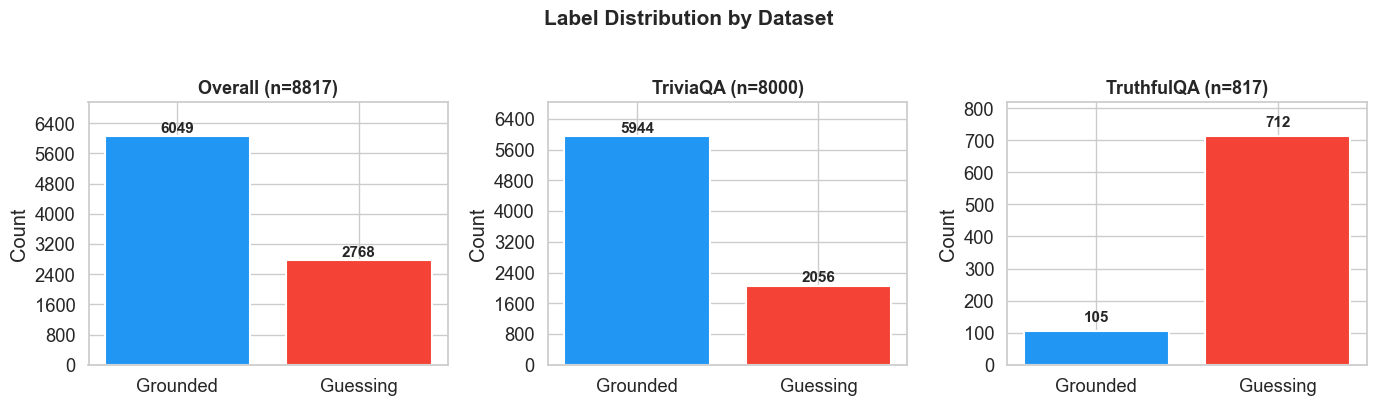

Saved: figures/01_label_distribution.png


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (src, title) in zip(axes, [
    ('all',        'Overall'),
    ('triviaqa',   'TriviaQA'),
    ('truthfulqa', 'TruthfulQA')
]):
    if src == 'all':
        subset = df
    else:
        subset = df[df['source'] == src]

    counts = subset['label'].value_counts().sort_index()
    labels_text = ['Grounded', 'Guessing']
    colors = [PALETTE['Grounded'], PALETTE['Guessing']]
    bars = ax.bar(labels_text, counts.values, color=colors, edgecolor='white', linewidth=1.5)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(f'{title} (n={len(subset)})', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.15)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle('Label Distribution by Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/01_label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/01_label_distribution.png')

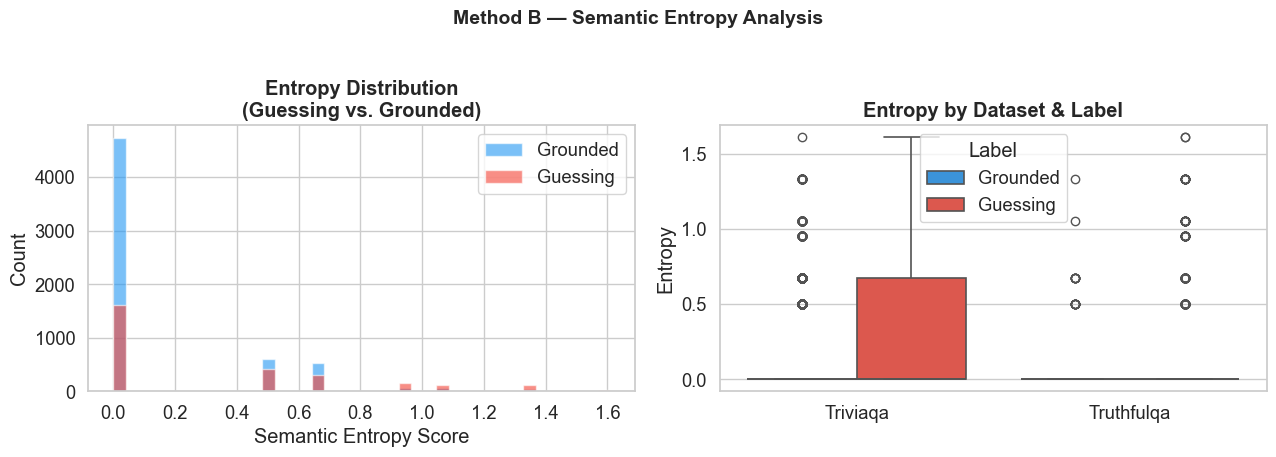

Saved: figures/02_entropy_distribution.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

label_map = {0: 'Grounded', 1: 'Guessing'}
df['label_str'] = df['label'].map(label_map)

for lbl, color in PALETTE.items():
    subset = df[df['label_str'] == lbl]['entropy_score']
    axes[0].hist(subset, bins=40, alpha=0.6, color=color, label=lbl, edgecolor='white')
axes[0].set_xlabel('Semantic Entropy Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Entropy Distribution\n(Guessing vs. Grounded)', fontweight='bold')
axes[0].legend()

# Box plot per source
df['label_str'] = df['label'].map(label_map)
plot_data = []
for src in ['triviaqa', 'truthfulqa']:
    for lbl in ['Grounded', 'Guessing']:
        vals = df[(df['source']==src) & (df['label_str']==lbl)]['entropy_score'].values
        for v in vals:
            plot_data.append({'Dataset': src.capitalize(), 'Label': lbl, 'Entropy': v})
plot_df = pd.DataFrame(plot_data)

sns.boxplot(data=plot_df, x='Dataset', y='Entropy', hue='Label',
            palette=PALETTE, ax=axes[1], linewidth=1.2)
axes[1].set_title('Entropy by Dataset & Label', fontweight='bold')
axes[1].set_xlabel('')

plt.suptitle('Method B — Semantic Entropy Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/02_entropy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/02_entropy_distribution.png')

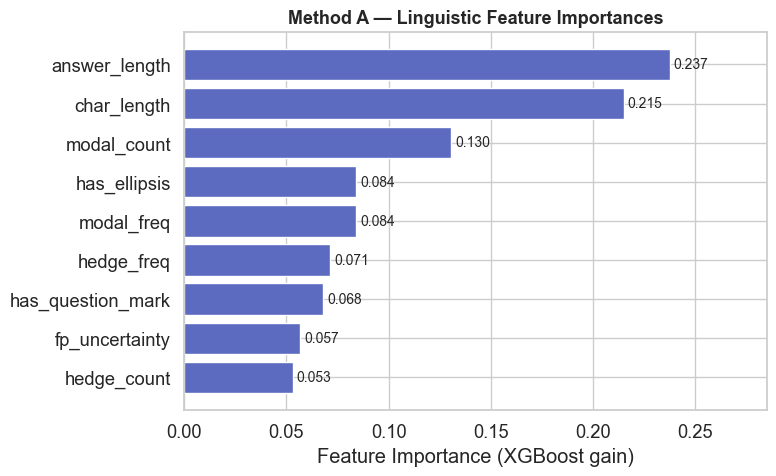

Saved: figures/03_feature_importance.png


In [33]:
feat_names = [
    'answer_length', 'hedge_count', 'hedge_freq', 'modal_count',
    'modal_freq', 'has_question_mark', 'has_ellipsis', 'fp_uncertainty', 'char_length'
]
importances = clf_A.feature_importances_
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color='#5C6BC0', edgecolor='white', linewidth=1)

for bar, val in zip(bars, feat_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.set_xlabel('Feature Importance (XGBoost gain)')
ax.set_title('Method A — Linguistic Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlim(0, feat_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('figures/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/03_feature_importance.png')

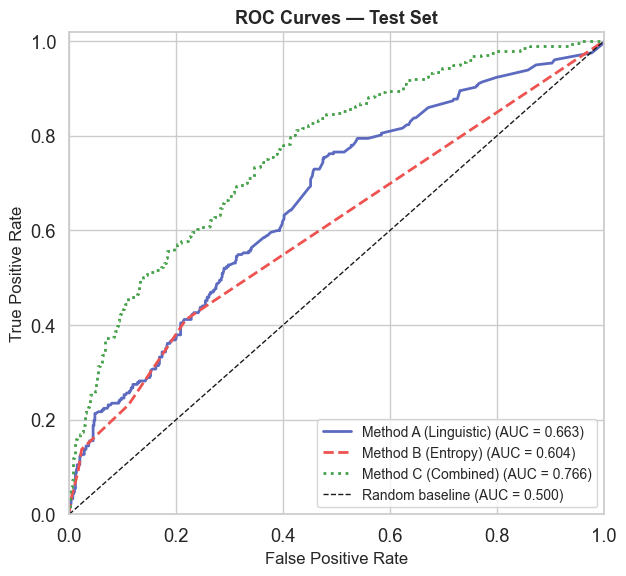

Saved: figures/04_roc_curves.png


In [34]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6.5, 6))

for label, probs, color, ls in [
    ('Method A (Linguistic)', prob_A_test, '#5C6BC0', '-'),
    ('Method B (Entropy)',    prob_B_test, '#EF5350', '--'),
    ('Method C (Combined)',   prob_C_test, '#43A047', ':'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle=ls,
            label=f'{label} (AUC = {auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random baseline (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('figures/04_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/04_roc_curves.png')


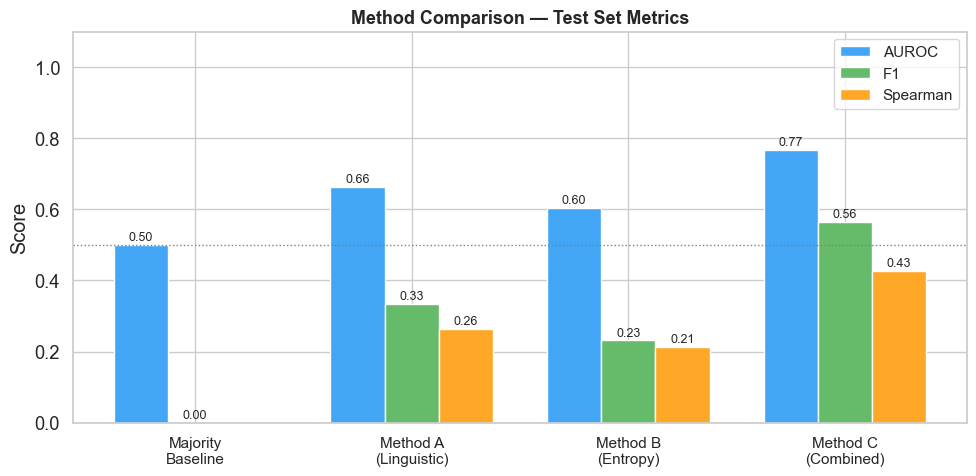

Saved: figures/05_metrics_comparison.png


In [35]:
methods  = ['Majority\nBaseline', 'Method A\n(Linguistic)', 'Method B\n(Entropy)', 'Method C\n(Combined)']
aurocs   = [res_baseline['auroc'],  res_A_test['auroc'],  res_B_test['auroc'],  res_C_test['auroc']]
f1s      = [res_baseline['f1'],     res_A_test['f1'],     res_B_test['f1'],     res_C_test['f1']]
spearmans= [res_baseline['spearman'],res_A_test['spearman'],res_B_test['spearman'],res_C_test['spearman']]

x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width, aurocs,    width, label='AUROC',    color='#42A5F5', edgecolor='white')
b2 = ax.bar(x,         f1s,       width, label='F1',       color='#66BB6A', edgecolor='white')
b3 = ax.bar(x + width, spearmans, width, label='Spearman', color='#FFA726', edgecolor='white')

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Method Comparison — Test Set Metrics', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.axhline(0.5, color='gray', linestyle=':', lw=1, label='Chance')
plt.tight_layout()
plt.savefig('figures/05_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/05_metrics_comparison.png')

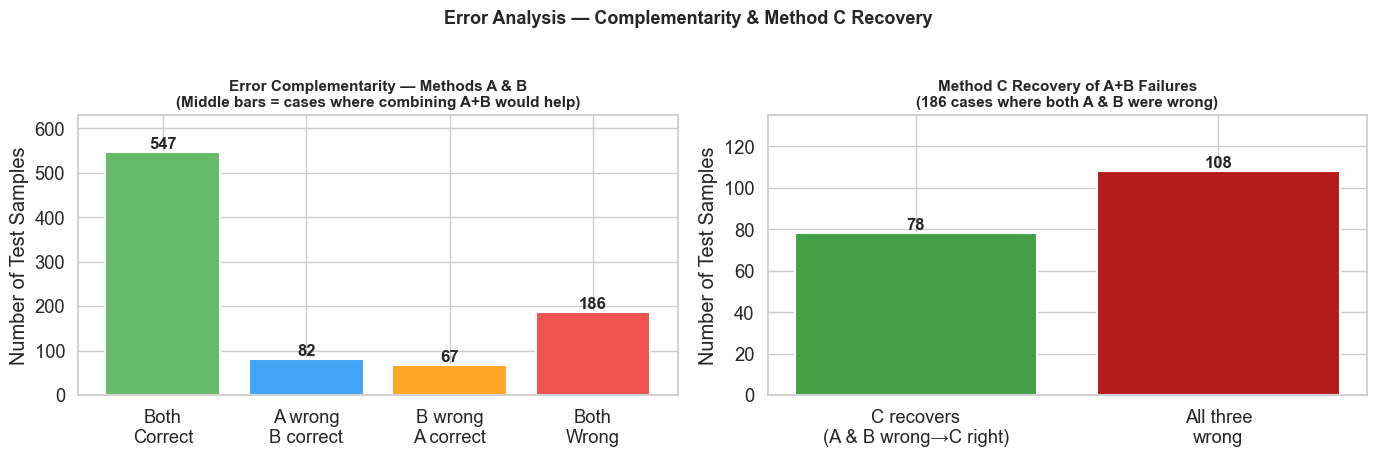

Saved: figures/06_error_complementarity.png


In [38]:
categories = ['Both\nCorrect', 'A wrong\nB correct', 'B wrong\nA correct', 'Both\nWrong']
counts_err = [both_right, a_wrong_b_right, b_wrong_a_right, both_wrong]
colors_err = ['#66BB6A', '#42A5F5', '#FFA726', '#EF5350']

c_recovers_both  = ab_wrong_c_right   
c_also_wrong     = both_wrong - c_recovers_both
c_wrong_a_right  = ((pred_A == y_test) & (pred_C != y_test)).sum()
c_wrong_b_right  = ((pred_B == y_test) & (pred_C != y_test)).sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

bars = axes[0].bar(categories, counts_err, color=colors_err, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts_err):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Test Samples')
axes[0].set_title('Error Complementarity — Methods A & B\n'
                  '(Middle bars = cases where combining A+B would help)', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(counts_err) * 1.15)

recov_cats   = ['C recovers\n(A & B wrong→C right)', 'All three\nwrong']
recov_counts = [c_recovers_both, c_also_wrong]
recov_colors = ['#43A047', '#B71C1C']
bars2 = axes[1].bar(recov_cats, recov_counts, color=recov_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars2, recov_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Test Samples')
axes[1].set_title(f'Method C Recovery of A+B Failures\n'
                  f'({both_wrong} cases where both A & B were wrong)', fontweight='bold', fontsize=11)
axes[1].set_ylim(0, max(recov_counts) * 1.25)

plt.suptitle('Error Analysis — Complementarity & Method C Recovery', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/06_error_complementarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/06_error_complementarity.png')

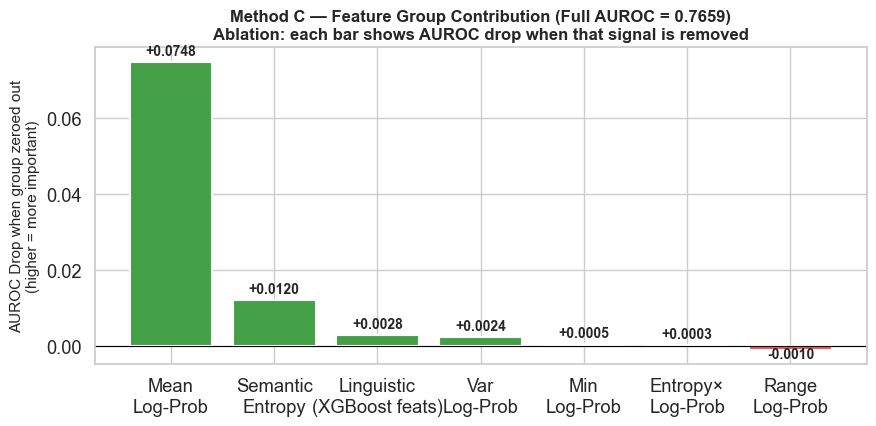

Saved: figures/07_method_c_signal_contribution.png

All figures saved to ./figures/


In [37]:
feature_groups = {
    'Linguistic\n(XGBoost feats)': list(range(0, 9)),
    'Semantic\nEntropy':           [9],
    'Mean\nLog-Prob':             [10],
    'Min\nLog-Prob':              [11],
    'Var\nLog-Prob':              [12],
    'Range\nLog-Prob':            [13],
    'Entropy×\nLog-Prob':         [14],
}

full_auroc = roc_auc_score(y_test, prob_C_test)

ablation_results = {}
for group_name, feat_indices in feature_groups.items():
    X_ablated = X_test_C_sc.copy()
    X_ablated[:, feat_indices] = 0.0       
    prob_ablated = predict_mlp(X_ablated)
    ablated_auroc = roc_auc_score(y_test, prob_ablated)
    ablation_results[group_name] = full_auroc - ablated_auroc   

group_names = list(ablation_results.keys())
drops       = list(ablation_results.values())

sorted_pairs = sorted(zip(drops, group_names), reverse=True)
drops_sorted, names_sorted = zip(*sorted_pairs)

colors_ablation = ['#43A047' if d > 0 else '#EF5350' for d in drops_sorted]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(names_sorted, drops_sorted, color=colors_ablation, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, drops_sorted):
    ypos = val + 0.001 if val >= 0 else val - 0.003
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f'{val:+.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(0, color='black', lw=0.8, linestyle='-')
ax.set_ylabel('AUROC Drop when group zeroed out\n(higher = more important)', fontsize=11)
ax.set_title(f'Method C — Feature Group Contribution (Full AUROC = {full_auroc:.4f})\n'
             f'Ablation: each bar shows AUROC drop when that signal is removed',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('figures/07_method_c_signal_contribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/07_method_c_signal_contribution.png')
print('\nAll figures saved to ./figures/')